In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import random

from pathlib import Path

import easyocr
from ultralytics import YOLO
import cv2

from py_files.pipeline import predict_license_plate

In [3]:
val_folder = Path("../data/cars/images/val")

In [4]:
model = YOLO("../models/best.pt")

reader = easyocr.Reader(
    ["en"],
    gpu=False
)

Using CPU. Note: This module is much faster with a GPU.


In [5]:
val_images = sorted(
    Path("../data/cars/images/val").glob("*.jpg")
)

Validation images: 1073


In [6]:
random.seed(42)

val_images = random.sample(
    val_images,
    50
)

In [7]:
rows = []

for image_path in val_images:
    result = predict_license_plate(
        image_path,
        model,
        reader,
        method="baseline"
    )
    rows.append({
        "image": image_path.name,
        "detected": result["detected"],
        "prediction": result["prediction"],
        "confidence": result["confidence"]
    })

results = pd.DataFrame(rows)
results.head()

C:\Users\User\PycharmProjects\JupyterProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,image,detected,prediction,confidence
0,2c602008a22124be.jpg,True,5543736,0.663598
1,03ae238ae9016ff5.jpg,True,570527,0.224648
2,83c416344cb2ae4e.jpg,True,NaN,NaN
3,73b689066698d3a2.jpg,True,EAP,0.087592
4,695582dbb6b564bc.jpg,True,NaN,NaN


In [15]:
print(f"Images: {len(results)}")
print(f"Detected: {results.detected.sum()}")
print(f"Detection rate: {results.detected.mean():.2%}")
print()
results["confidence"].describe()

Images: 50
Detected: 48
Detection rate: 96.00%



count    42.000000
mean      0.483921
std       0.323669
min       0.000000
25%       0.213681
50%       0.565501
75%       0.735385
max       0.999920
Name: confidence, dtype: float64

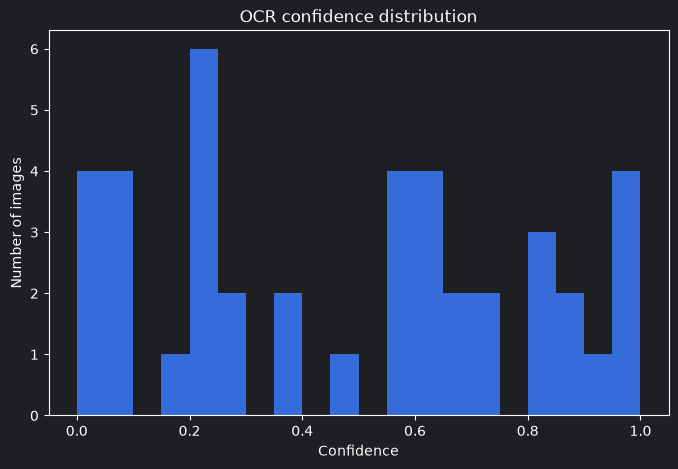

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    results["confidence"],
    bins=20
)

plt.xlabel("Confidence")
plt.ylabel("Number of images")

plt.title("OCR confidence distribution")

plt.show()

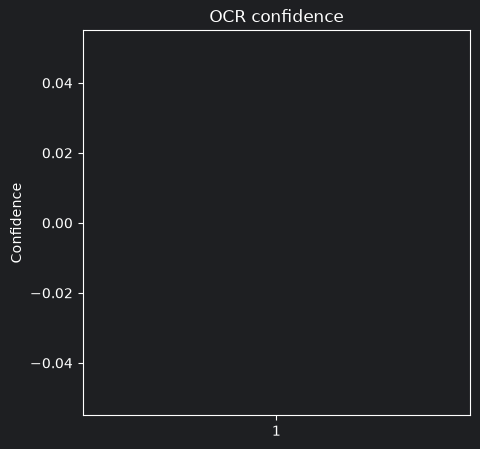

In [17]:
plt.figure(figsize=(5,5))

plt.boxplot(
    results["confidence"]
)

plt.ylabel("Confidence")

plt.title("OCR confidence")

plt.show()

In [18]:
results.nlargest(
    10,
    "confidence"
)

,image,detected,prediction,confidence
9,06bf917a1448f872.jpg,True,FINMUN,0.999920
45,897e2a57af50208e.jpg,True,D,0.996861
16,5c55cf36942578fd.jpg,True,X458FCB,0.991732
10,063b8572725e4df0.jpg,True,WA42439,0.950194
33,7d6deeed0deb693c.jpg,True,X428KOC,0.944477
48,d90850d40a2635c4.jpg,True,B18405SU,0.859587
17,c98faf510dea2441.jpg,True,ETH855T,0.858772
49,adaf69fd55845e8f.jpg,True,FC5800,0.836830
47,2799cab694b8824b.jpg,True,2VAB577,0.829890
6,282dec3d0f36d111.jpg,True,MNFNVHILLSBOROUGHFLORIDAL778LA94501791082,0.801993


In [12]:
results.nsmallest(
    10,
    "confidence"
)

,image,detected,prediction,confidence
19,d73b9432eeb054da.jpg,False,NaN,0.000000
25,4788b66421158402.jpg,False,NaN,0.000000
30,2649511b64ff5498.jpg,True,LB96Z71,0.028532
29,b3af7ee4a409cd58.jpg,True,M0176,0.033533
40,abc1dd3af4a82bc6.jpg,True,845945J0I,0.069751
22,49744a5ed834195a.jpg,True,CRBS,0.078668
3,73b689066698d3a2.jpg,True,EAP,0.087592
35,dc8823ab8a8dbe6a.jpg,True,J4S359,0.093968
24,a05108d1178fa437.jpg,True,DWC7IO,0.170029
8,cafc97ebc49704ba.jpg,True,E848552,0.208784


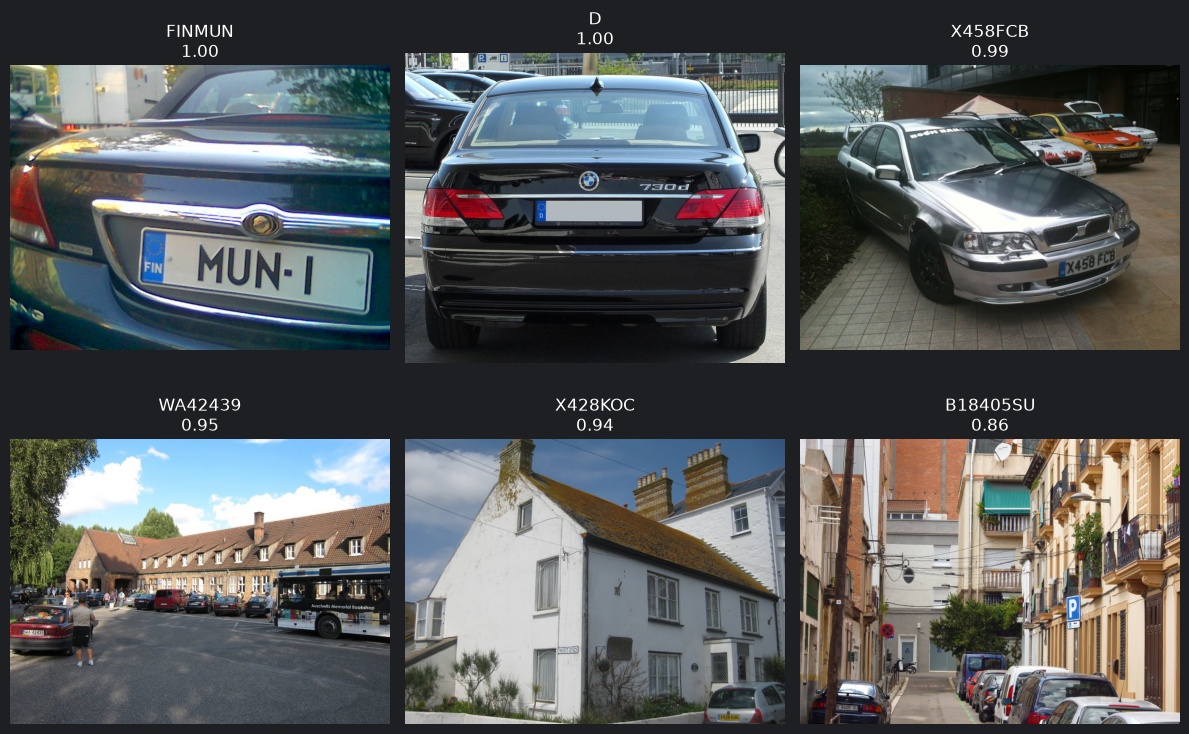

In [13]:
best = results.nlargest(
    6,
    "confidence"
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12,8)
)

for ax, (_, row) in zip(
    axes.flatten(),
    best.iterrows()
):

    image = cv2.imread(
        str(val_folder / row.image)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image)

    ax.set_title(
        f"{row.prediction}\n{row.confidence:.2f}"
    )

    ax.axis("off")

plt.tight_layout()

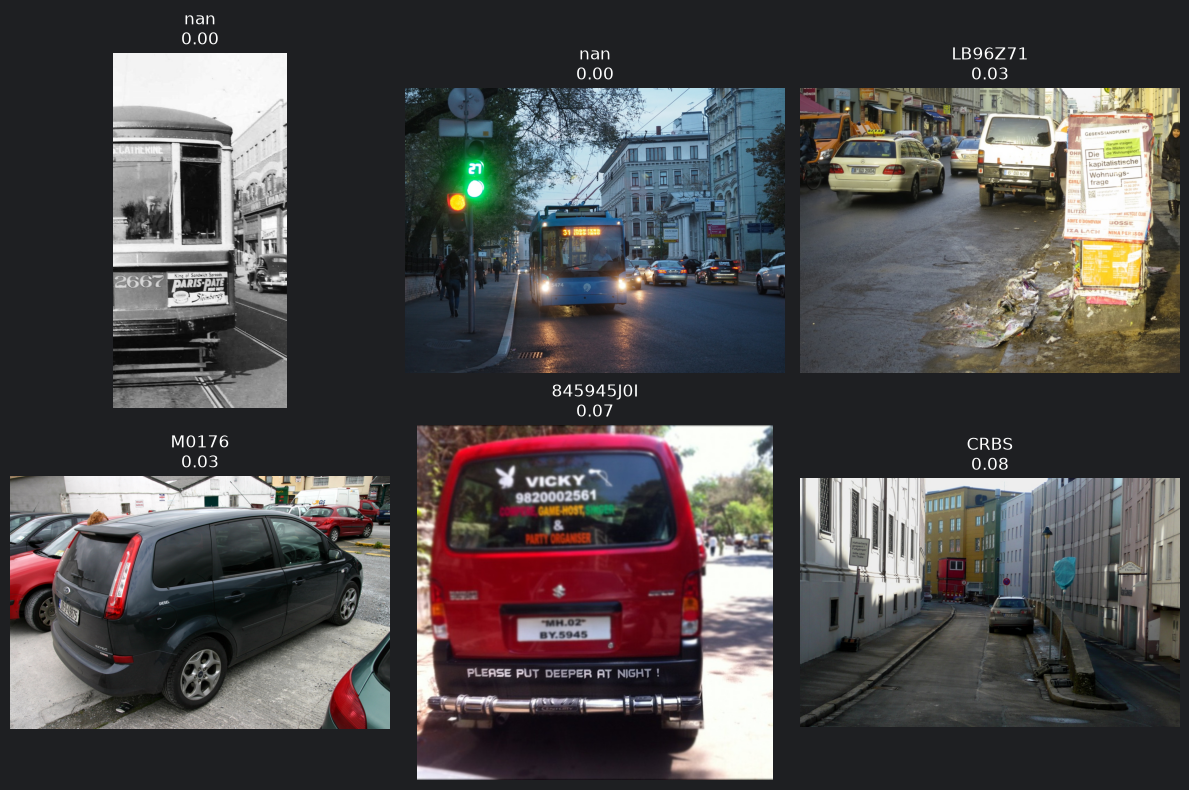

In [14]:
worst = results.nsmallest(
    6,
    "confidence"
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12,8)
)

for ax, (_, row) in zip(
    axes.flatten(),
    worst.iterrows()
):

    image = cv2.imread(
        str(val_folder / row.image)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image)

    ax.set_title(
        f"{row.prediction}\n{row.confidence:.2f}"
    )

    ax.axis("off")

plt.tight_layout()

In [19]:
detected = results["detected"].sum()

not_detected = len(results) - detected

print(f"Detected plates: {detected}")
print(f"Missed plates: {not_detected}")
print(f"Detection rate: {detected/len(results):.2%}")

Detected plates: 48
Missed plates: 2
Detection rate: 96.00%
